In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNccm95bGFcRG9jdW1lbnRzXHF1YXJ0by1naXNccmVzZWFyY2hcYW5hbHlzaXM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib\\importlib\\_bootstrap.py": 1713272302.1423218, "C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib\\importlib\\_bootstrap_external.py": 1713272302.1433752, "C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib\\zipimport.py": 1713272317.3834581, "C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib\\codecs.py": 1713272296.2660067, "C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib\\encodings\\aliases.py": 1713272300.4022787, "C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib\\encodings\\__init__.py": 1713272300.5643764, "C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8

In [2]:
#| label: setup

import json
import sys
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
from folium.plugins import Fullscreen, MiniMap, MousePosition

sys.path.append("..")

# Load site data
with open("StoneTowerSites.json", encoding="utf-8") as f:
	sites = json.load(f)
sites_df = pd.DataFrame(sites)

# Check prettymaps availability
try:
	import prettymaps
	from importlib.metadata import version as _pkg_version
	HAS_PRETTYMAPS = True
	try:
		_pm_ver = _pkg_version("prettymaps")
	except Exception:
		_pm_ver = "unknown"
	print(f"prettymaps {_pm_ver} available")
except ImportError:
	HAS_PRETTYMAPS = False
	print("prettymaps not found — install with: pip install prettymaps")

print(f"\nLoaded {len(sites)} tower site clusters")
print(sites_df[["name", "ethnic_group", "tower_count"]].to_string(index=False))

prettymaps 1.4.2 available

Loaded 7 tower site clusters
                 name            ethnic_group                    tower_count
Danba / Suopo Cluster        Gyalrong Tibetan 13+ documented (Suopo cluster)
    Maerkang (Barkam)        Gyalrong Tibetan     Dozens; partially surveyed
      Jinchuan County        Gyalrong Tibetan     Dozens; partially surveyed
       Heishui County                   Qiang     Scores; partially surveyed
       Songpan County                   Qiang     Scattered; poorly surveyed
    Chamdo Prefecture Tibetan (mixed/unknown)  Few confirmed; access limited
     Yushu Prefecture Tibetan (mixed/unknown)  Tentative; survey data sparse


In [3]:
#| label: site-table
#| tbl-cap: Documented stone tower site clusters. Tower counts are estimates based on available surveys.

display_df = sites_df[[
	"name", "county", "ethnic_group", "tower_count", "plan_types", "status", "period"
]].copy()
display_df.columns = [
	"Site Cluster", "County", "Ethnic Group", "Tower Count", "Plan Types", "Protection Status", "Period"
]

display_df.style\
	.set_properties(**{"font-size": "0.87em"})\
	.set_table_styles([
		{"selector": "th", "props": [
			("background-color", "#7c3d12"),
			("color", "#faf8f4"),
			("font-size", "0.85em"),
			("padding", "6px 10px"),
		]},
		{"selector": "td", "props": [("padding", "5px 10px")]},
		{"selector": "tr:nth-child(even)", "props": [("background-color", "#fef9ec")]},
	])\
	.hide(axis="index")

Site Cluster,County,Ethnic Group,Tower Count,Plan Types,Protection Status,Period
Danba / Suopo Cluster,Danba (丹巴县),Gyalrong Tibetan,13+ documented (Suopo cluster),Square to 13-pointed star,WMF Watch 2006 / Provincial Protected,~10th–18th c.
Maerkang (Barkam),Maerkang (马尔康市),Gyalrong Tibetan,Dozens; partially surveyed,"Square, hexagonal",Provincial Protected (selected sites),~12th–18th c.
Jinchuan County,Jinchuan (金川县),Gyalrong Tibetan,Dozens; partially surveyed,"Square, star (6-pointed)",Provincial Protected (selected sites),~14th–18th c.
Heishui County,Heishui (黑水县),Qiang,Scores; partially surveyed,"Square, rectangular",Some Provincial Protected,~8th–16th c.
Songpan County,Songpan (松潘县),Qiang,Scattered; poorly surveyed,Square,Limited formal protection,~8th–14th c.
Chamdo Prefecture,Chamdo (昌都市),Tibetan (mixed/unknown),Few confirmed; access limited,Square (inferred),Limited formal protection,Unknown; possibly pre-10th c.
Yushu Prefecture,Yushu (玉树市),Tibetan (mixed/unknown),Tentative; survey data sparse,Unknown,Post-earthquake heritage survey ongoing,Unknown


In [4]:
#| label: folium-map
#| fig-cap: Seven documented tower site clusters across western Sichuan and eastern Tibet. Relief basemap by Esri. Toggle 'Label Overlay' for place names.

# ---------------------------------------------------------------------------
# Ethnic group color palette
# ---------------------------------------------------------------------------
GROUP_COLORS = {
	"Gyalrong Tibetan": "#a16207",    # amber/gold
	"Qiang": "#be185d",               # rose
	"Tibetan (mixed/unknown)": "#6b7280",  # slate
}

def make_div_icon(color, size=20):
	"""Circular DivIcon with drop shadow."""
	return folium.DivIcon(
		icon_size=(size, size),
		icon_anchor=(size // 2, size // 2),
		html=(
			f'<div style="'
			f'width:{size}px;height:{size}px;'
			f'border-radius:50%;'
			f'background:{color};'
			f'border:2.5px solid white;'
			f'box-shadow:0 1px 4px rgba(0,0,0,0.45);'
			f'"></div>'
		),
	)

def make_popup(site):
	"""Styled HTML popup card."""
	color = GROUP_COLORS.get(site["ethnic_group"], "#6b7280")
	return folium.Popup(
		folium.IFrame(
			html=(
				'<div style="font-family:\'Inter\',sans-serif;padding:4px;">'
				f'<h4 style="margin:0 0 6px;color:#7c3d12;font-size:1em;">{site["name"]}</h4>'
				'<table style="width:100%;font-size:0.82em;border-collapse:collapse;">'
				f'<tr><td style="color:#78716c;padding:2px 4px 2px 0;white-space:nowrap;">County</td>'
				f'<td style="padding:2px 0;">{site["county"]}</td></tr>'
				f'<tr><td style="color:#78716c;padding:2px 4px 2px 0;">Prefecture</td>'
				f'<td>{site["prefecture"]}</td></tr>'
				f'<tr><td style="color:#78716c;padding:2px 4px 2px 0;">Ethnic group</td>'
				f'<td><span style="color:{color};font-weight:600;">{site["ethnic_group"]}</span></td></tr>'
				f'<tr><td style="color:#78716c;padding:2px 4px 2px 0;">Towers</td>'
				f'<td>{site["tower_count"]}</td></tr>'
				f'<tr><td style="color:#78716c;padding:2px 4px 2px 0;">Plan types</td>'
				f'<td>{site["plan_types"]}</td></tr>'
				f'<tr><td style="color:#78716c;padding:2px 4px 2px 0;">Period</td>'
				f'<td>{site["period"]}</td></tr>'
				f'<tr><td style="color:#78716c;padding:2px 4px 2px 0;">Status</td>'
				f'<td>{site["status"]}</td></tr>'
				'</table>'
				f'<p style="font-size:0.78em;color:#78716c;margin:6px 0 0;font-style:italic;">'
				f'{site["notes"]}</p>'
				'</div>'
			),
			width=310, height=230,
		),
		max_width=330,
	)

# ---------------------------------------------------------------------------
# Base map — Esri Shaded Relief for mountain terrain context
# ---------------------------------------------------------------------------
m = folium.Map(
	location=[31.5, 100.5],
	zoom_start=6,
	tiles=None,
)

# Primary tile: Esri WorldShadedRelief
folium.TileLayer(
	tiles=(
		"https://server.arcgisonline.com/ArcGIS/rest/services/"
		"World_Shaded_Relief/MapServer/tile/{z}/{y}/{x}"
	),
	attr="Tiles &copy; Esri",
	name="Esri Shaded Relief",
	control=True,
).add_to(m)

# Optional label overlay
folium.TileLayer(
	tiles="https://{s}.basemaps.cartocdn.com/rastertiles/voyager_only_labels/{z}/{x}/{y}{r}.png",
	attr='&copy; <a href="https://carto.com/">CARTO</a>',
	name="Label Overlay",
	overlay=True,
	show=False,
	opacity=0.85,
).add_to(m)

# ---------------------------------------------------------------------------
# Plot site markers by ethnic group
# ---------------------------------------------------------------------------
for site in sites:
	color = GROUP_COLORS.get(site["ethnic_group"], "#6b7280")
	folium.Marker(
		location=[site["lat"], site["lon"]],
		popup=make_popup(site),
		tooltip=folium.Tooltip(
			"<b>" + site["name"] + "</b><br>"
			+ "<span style='color:" + color + ";'>" + site["ethnic_group"] + "</span>"
		),
		icon=make_div_icon(color, size=22),
	).add_to(m)

# ---------------------------------------------------------------------------
# Legend
# ---------------------------------------------------------------------------
legend_html = """
<div style="
	position:fixed;bottom:30px;left:30px;
	background:rgba(250,248,244,0.95);
	border:1px solid #c4a882;border-radius:6px;
	padding:10px 14px;font-family:'Inter',sans-serif;
	font-size:12px;z-index:9999;
	box-shadow:0 2px 6px rgba(0,0,0,0.2);
">
<b style="color:#7c3d12;font-size:13px;">Ethnic Group</b><br>
<span style="display:inline-block;width:12px;height:12px;border-radius:50%;
	background:#a16207;margin:4px 5px 0 0;border:2px solid white;
	box-shadow:0 1px 3px rgba(0,0,0,0.3);"></span>Gyalrong Tibetan<br>
<span style="display:inline-block;width:12px;height:12px;border-radius:50%;
	background:#be185d;margin:4px 5px 0 0;border:2px solid white;
	box-shadow:0 1px 3px rgba(0,0,0,0.3);"></span>Qiang<br>
<span style="display:inline-block;width:12px;height:12px;border-radius:50%;
	background:#6b7280;margin:4px 5px 0 0;border:2px solid white;
	box-shadow:0 1px 3px rgba(0,0,0,0.3);"></span>Tibetan (mixed/unknown)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ---------------------------------------------------------------------------
# Plugins: Fullscreen, MiniMap, MousePosition
# ---------------------------------------------------------------------------
Fullscreen(
	position="topright",
	title="Fullscreen",
	title_cancel="Exit fullscreen",
).add_to(m)

_minimap_tile = folium.TileLayer(
	tiles=(
		"https://server.arcgisonline.com/ArcGIS/rest/services/"
		"World_Shaded_Relief/MapServer/tile/{z}/{y}/{x}"
	),
	attr="Tiles &copy; Esri",
	name="minimap-relief",
)
MiniMap(
	tile_layer=_minimap_tile,
	position="bottomright",
	toggle_display=True,
	width=140,
	height=100,
).add_to(m)

MousePosition(
	position="bottomleft",
	separator=" | ",
	prefix="Lat/Lon:",
	num_digits=4,
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

m

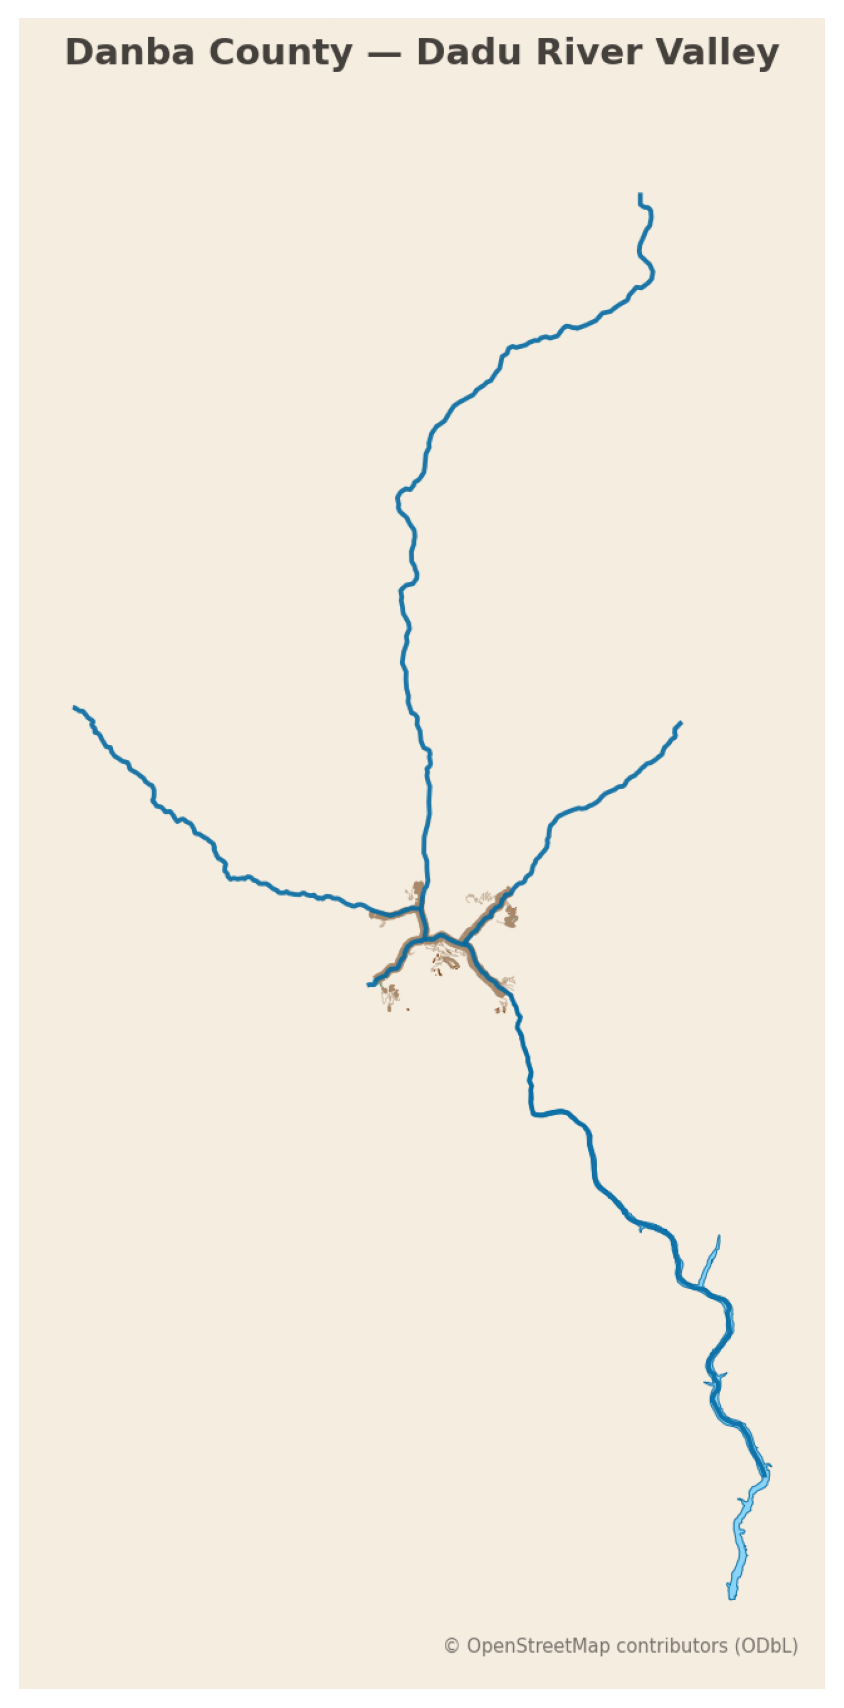

In [5]:
#| label: danba-local-map
#| fig-cap: OpenStreetMap data rendered via osmnx + matplotlib. Danba County seat and surroundings, ~4 km radius. Buildings (tan), streets (warm ochre), waterways (sky blue), vegetation (sage green). Data © OpenStreetMap contributors (ODbL). Generated by generate_danba_map.py.

# Pre-generated by generate_danba_map.py — no network call at render time
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("_export_images/danba-osmnx.png")
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(img)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [6]:
#| label: plan-geometry-chart
#| fig-cap: Estimated distribution of tower plan types. Star-plan towers are concentrated in Danba County and are associated with high-status Gyalrong Tibetan builders.

plan_data = pd.DataFrame([
	{"Plan Type": "Square", "Estimated %": 55, "tradition": "Qiang + Gyalrong"},
	{"Plan Type": "Hexagonal", "Estimated %": 18, "tradition": "Gyalrong"},
	{"Plan Type": "Octagonal", "Estimated %": 10, "tradition": "Gyalrong"},
	{"Plan Type": "Star (5–6 pt)", "Estimated %": 9, "tradition": "Gyalrong"},
	{"Plan Type": "Star (8–13 pt)", "Estimated %": 8, "tradition": "Gyalrong (elite)"},
])

import plotly.express as px

fig = px.bar(
	plan_data,
	x="Plan Type",
	y="Estimated %",
	color="tradition",
	color_discrete_map={
		"Qiang + Gyalrong": "#78716c",
		"Gyalrong": "#a16207",
		"Gyalrong (elite)": "#7c3d12",
	},
	labels={"Estimated %": "Estimated Share (%)", "tradition": "Tradition"},
	title="Approximate Distribution of Tower Plan Types",
)
fig.update_layout(
	height=340,
	width=680,
	plot_bgcolor="white",
	paper_bgcolor="#faf8f4",
	margin=dict(l=50, r=30, t=50, b=50),
	showlegend=True,
	legend_title_text="Tradition",
)
fig.update_traces(marker_line_width=0.5, marker_line_color="white")
fig.show()

In [7]:
#| label: comparative-table
#| tbl-cap: Comparative tower-building traditions worldwide. The Sichuan diaolou are globally unique in combining dry-stone construction, star-plan geometry, and heights exceeding 50 m in a seismically active zone.

comp = pd.DataFrame([
	{
		"Tradition": "Sichuan diaolou",
		"Location": "W. Sichuan / E. Tibet",
		"Period": "~6th–18th c.",
		"Material": "Dry stone",
		"Max Height": "~60 m",
		"Plan Forms": "Square to 13-star",
	},
	{
		"Tradition": "Svaneti towers",
		"Location": "Georgia (Caucasus)",
		"Period": "9th–13th c.",
		"Material": "Stone/mortar",
		"Max Height": "~25 m",
		"Plan Forms": "Square",
	},
	{
		"Tradition": "San Gimignano",
		"Location": "Tuscany, Italy",
		"Period": "12th–14th c.",
		"Material": "Stone/mortar",
		"Max Height": "~54 m",
		"Plan Forms": "Square",
	},
	{
		"Tradition": "Kaiping diaolou",
		"Location": "Guangdong, China",
		"Period": "19th–20th c.",
		"Material": "Brick/concrete",
		"Max Height": "~30 m",
		"Plan Forms": "Square/rectangular",
	},
	{
		"Tradition": "Tower houses of Shibam",
		"Location": "Yemen",
		"Period": "16th c.+",
		"Material": "Mud brick",
		"Max Height": "~30 m",
		"Plan Forms": "Square",
	},
	{
		"Tradition": "Nuraghi",
		"Location": "Sardinia",
		"Period": "~1900–730 BCE",
		"Material": "Dry stone",
		"Max Height": "~20 m",
		"Plan Forms": "Circular",
	},
])

comp.style\
	.set_properties(**{"font-size": "0.87em"})\
	.set_table_styles([
		{"selector": "th", "props": [
			("background-color", "#7c3d12"),
			("color", "#faf8f4"),
			("font-size", "0.84em"),
			("padding", "6px 10px"),
		]},
		{"selector": "td", "props": [("padding", "5px 10px")]},
		{"selector": "tr:nth-child(odd)", "props": [("background-color", "#fefce8")]},
		{"selector": "tr:first-child td", "props": [
			("font-weight", "600"),
			("color", "#7c3d12"),
		]},
	])\
	.hide(axis="index")

Tradition,Location,Period,Material,Max Height,Plan Forms
Sichuan diaolou,W. Sichuan / E. Tibet,~6th–18th c.,Dry stone,~60 m,Square to 13-star
Svaneti towers,Georgia (Caucasus),9th–13th c.,Stone/mortar,~25 m,Square
San Gimignano,"Tuscany, Italy",12th–14th c.,Stone/mortar,~54 m,Square
Kaiping diaolou,"Guangdong, China",19th–20th c.,Brick/concrete,~30 m,Square/rectangular
Tower houses of Shibam,Yemen,16th c.+,Mud brick,~30 m,Square
Nuraghi,Sardinia,~1900–730 BCE,Dry stone,~20 m,Circular


In [8]:
#| label: environment
#| code-fold: false

import sys, platform, folium, pandas as pd, matplotlib

print("Environment")
print(f"  Python:     {sys.version.split()[0]}")
print(f"  Platform:   {platform.system()} {platform.release()}")
print(f"  pandas:     {pd.__version__}")
print(f"  folium:     {folium.__version__}")
print(f"  matplotlib: {matplotlib.__version__}")
import osmnx as ox
print(f"  osmnx:      {ox.__version__}")

print("\nData Sources")
print("  StoneTowerSites.json   — 7 curated site clusters (this project)")
print("  stonetowerstibet.md    — primary scholarly source document")
print("  Esri WorldShadedRelief — terrain basemap (ArcGIS REST)")
print("  CARTO Voyager Labels   — label overlay (optional)")
print("  OpenStreetMap          — prettymaps base data")
print("  \u00a9 OpenStreetMap contributors (ODbL)")

print("\nSite Summary")
print(f"  Total sites: {len(sites)}")
for grp, cnt in sites_df.groupby("ethnic_group").size().items():
	print(f"  {grp}: {cnt} clusters")

Environment
  Python:     3.11.9
  Platform:   Windows 10
  pandas:     2.2.2
  folium:     0.20.0
  matplotlib: 3.10.8
  osmnx:      1.9.4

Data Sources
  StoneTowerSites.json   — 7 curated site clusters (this project)
  stonetowerstibet.md    — primary scholarly source document
  Esri WorldShadedRelief — terrain basemap (ArcGIS REST)
  CARTO Voyager Labels   — label overlay (optional)
  OpenStreetMap          — prettymaps base data
  © OpenStreetMap contributors (ODbL)

Site Summary
  Total sites: 7
  Gyalrong Tibetan: 3 clusters
  Qiang: 2 clusters
  Tibetan (mixed/unknown): 2 clusters
